In [ ]:
!pip install qiskit
!pip install qiskit-aer
!pip install matplotlib pylatexenc

Balanced oracle result: {'1': 100}


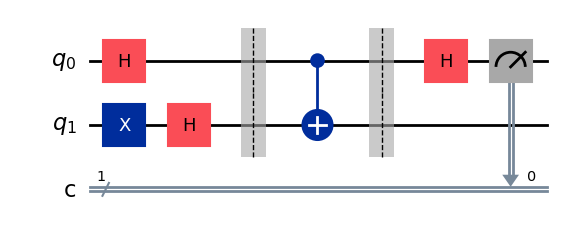

Constant(0) oracle result: {'0': 100}


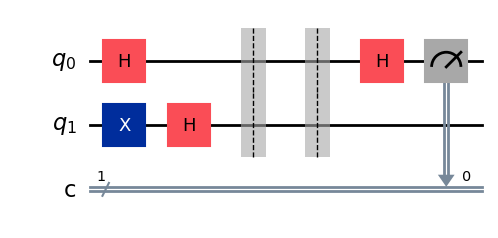

Constant(1) oracle result: {'0': 100}


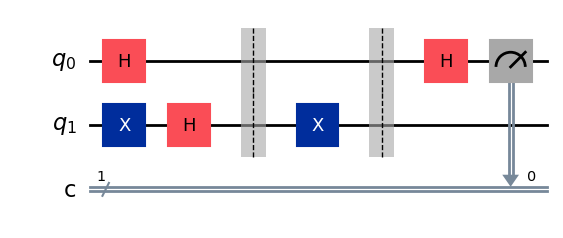

In [ ]:

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
def initialcircuit():
  qc=QuantumCircuit(2,1)
  qc.x(1)
  qc.h(0)
  qc.h(1)
  qc.barrier()
  return qc

def constant_oracle1():
  qc=QuantumCircuit(2,1)
  qc.x(1) # f(x)= 1 thats why used not gate
  qc.barrier()
  return qc

def balanced_oracle():
  qc=QuantumCircuit(2,1)
  qc.cx(0,1)
  qc.barrier()
  return qc

def constant_oracle0():
  qc=QuantumCircuit(2,1)
  qc.barrier()
  return qc

def measure():
  qc=QuantumCircuit(2,1)
  qc.h(0)
  qc.measure(0,0)
  return qc

simulator = AerSimulator()

for name, oracle in [("Balanced", balanced_oracle()),("Constant(0)", constant_oracle0()),("Constant(1)",constant_oracle1())]:
    qc = initialcircuit()
    qc=qc.compose(oracle)
    qc=qc.compose(measure())


    result = simulator.run(qc, shots=100).result()
    counts = result.get_counts()

    print(f"{name} oracle result:", counts)
    display(qc.draw("mpl"))